In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import our modeling and evaluation tools
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Load data
X_train = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test = pd.read_csv("../data/processed/X_test_scaled.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel() # .ravel() keeps it 1D for sklearn
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Data loaded successfully. Ready to train!")

Data loaded successfully. Ready to train!


In [2]:
# 1. Initialize the models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# 2. Train Random Forest
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Train XGBoost
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("Both models trained perfectly!")

Training Random Forest...
Training XGBoost...
Both models trained perfectly!


In [3]:
# Random Forest predictions
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# XGBoost predictions
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(f"Random Forest Test Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"XGBoost Test Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

Random Forest Test Accuracy: 0.9796
XGBoost Test Accuracy: 0.9388


In [4]:
print("Random Forest Report")
print(classification_report(y_test, rf_preds, target_names=['No Fire', 'Fire']))
print("XGBOOST Report")
print(classification_report(y_test, xgb_preds, target_names=['No Fire', 'Fire']))

Random Forest Report
              precision    recall  f1-score   support

     No Fire       1.00      0.95      0.98        21
        Fire       0.97      1.00      0.98        28

    accuracy                           0.98        49
   macro avg       0.98      0.98      0.98        49
weighted avg       0.98      0.98      0.98        49

XGBOOST Report
              precision    recall  f1-score   support

     No Fire       1.00      0.86      0.92        21
        Fire       0.90      1.00      0.95        28

    accuracy                           0.94        49
   macro avg       0.95      0.93      0.94        49
weighted avg       0.94      0.94      0.94        49



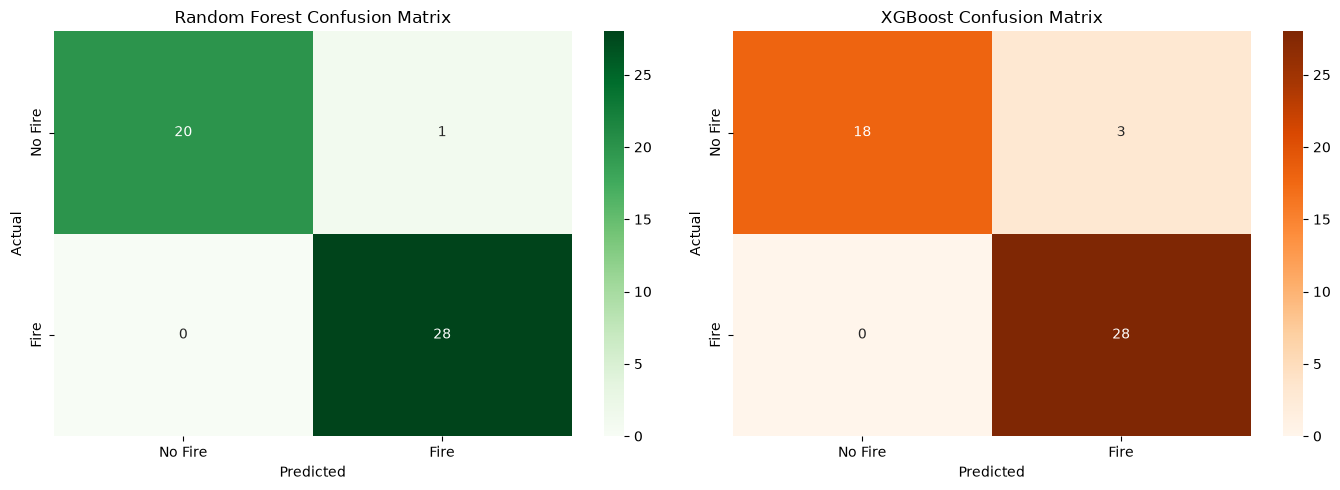

In [5]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# XGBoost Confusion Matrix
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

C:\Users\kshitija\AppData\Local\Temp\ipykernel_15776\1304586125.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


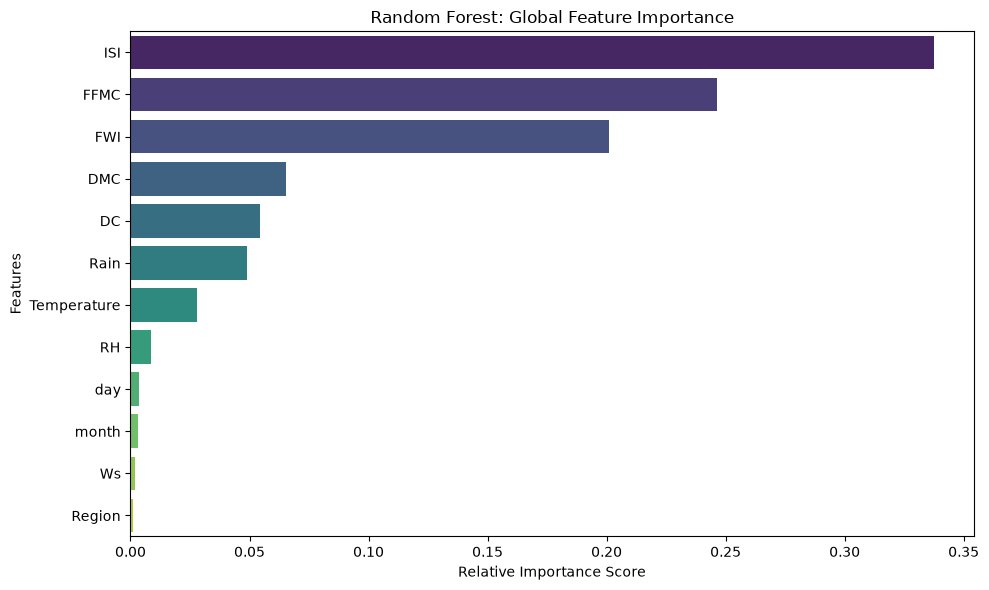

In [6]:
# Extract feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort them in descending order
indices = np.argsort(importances)[::-1]

# Plot the features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Random Forest: Global Feature Importance")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()